# Étude d'ablation — nombre de pas de diffusion (T)

Compare 3 configs identiques (architecture, seed=42, budget d'entraînement=500 steps) ne différant que par `timesteps` (`configs/ddpm_ablation_steps{100,400,1000}.yaml`) : qualité de génération vs temps d'entraînement/génération (checklist "Étude d'ablation" de `TASKS.md`).

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

root = Path.cwd().parent
configs = [100, 400, 1000]
exp_dirs = {t: root / "experiments" / f"ddpm_ablation_steps{t}" for t in configs}

summaries = {}
logs = {}
for t, d in exp_dirs.items():
    summaries[t] = json.load(open(d / "summary.json"))
    logs[t] = pd.read_csv(d / "log.csv")

df = pd.DataFrame(summaries).T
df.index.name = "timesteps"
df

,config,timesteps,num_train_steps,total_train_time_s,final_loss_avg_last20,generation_time_s,n_samples_generated
timesteps,,,,,,,
100,configs/ddpm_ablation_steps100.yaml,100,500,3295.66,0.1107,13.37,8
400,configs/ddpm_ablation_steps400.yaml,400,500,3667.63,0.0648,51.97,8
1000,configs/ddpm_ablation_steps1000.yaml,1000,500,3798.78,0.0404,129.03,8


## Tableau comparatif — base de la section "Étude d'ablation" du rapport

In [2]:
table = df[["total_train_time_s", "generation_time_s", "final_loss_avg_last20"]].copy()
table["generation_time_per_image_s"] = table["generation_time_s"] / 8
table.columns = ["Temps entraînement (s)", "Temps génération 8 img (s)", "Loss finale (moy. 20 derniers)", "Temps génération / image (s)"]
table

,Temps entraînement (s),Temps génération 8 img (s),Loss finale (moy. 20 derniers),Temps génération / image (s)
timesteps,,,,
100,3295.66,13.37,0.1107,1.67125
400,3667.63,51.97,0.0648,6.49625
1000,3798.78,129.03,0.0404,16.12875


## Temps de génération vs nombre de pas de diffusion

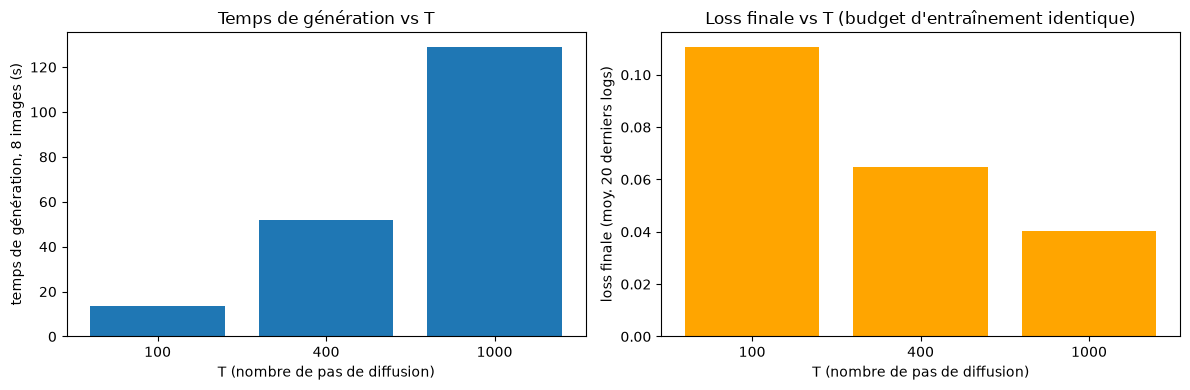

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar([str(t) for t in configs], [summaries[t]["generation_time_s"] for t in configs])
axes[0].set_xlabel("T (nombre de pas de diffusion)")
axes[0].set_ylabel("temps de génération, 8 images (s)")
axes[0].set_title("Temps de génération vs T")

axes[1].bar([str(t) for t in configs], [summaries[t]["final_loss_avg_last20"] for t in configs], color="orange")
axes[1].set_xlabel("T (nombre de pas de diffusion)")
axes[1].set_ylabel("loss finale (moy. 20 derniers logs)")
axes[1].set_title("Loss finale vs T (budget d'entraînement identique)")

plt.tight_layout()
plt.show()

## Courbes de loss d'entraînement superposées

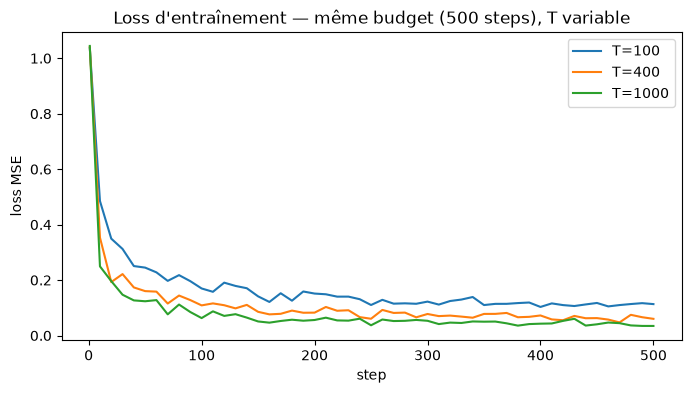

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
for t in configs:
    ax.plot(logs[t]["step"], logs[t]["loss"], label=f"T={t}")
ax.set_xlabel("step")
ax.set_ylabel("loss MSE")
ax.set_title("Loss d'entraînement — même budget (500 steps), T variable")
ax.legend()
plt.show()

## Comparaison visuelle des échantillons finaux (step 500)

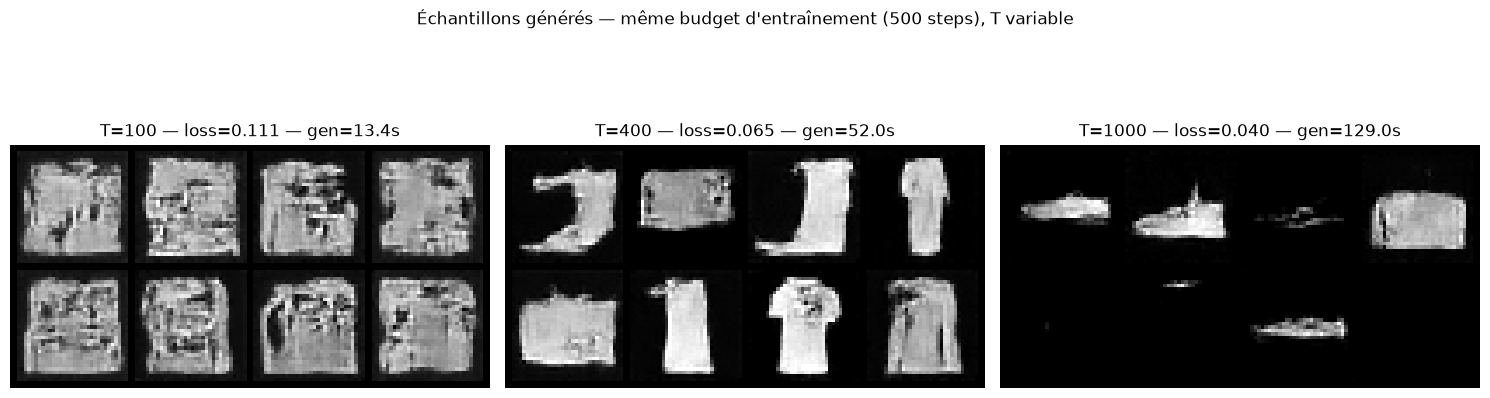

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, t in zip(axes, configs):
    img = Image.open(exp_dirs[t] / "samples" / "step_000500.png")
    ax.imshow(img, cmap="gray")
    ax.set_title(f"T={t} — loss={summaries[t]['final_loss_avg_last20']:.3f} — gen={summaries[t]['generation_time_s']:.1f}s")
    ax.axis("off")
plt.suptitle("Échantillons générés — même budget d'entraînement (500 steps), T variable")
plt.tight_layout()
plt.show()

## Observations — base de la section "Étude d'ablation" du rapport

- **Temps de génération** : quasi linéaire en `T`, comme attendu (`p_sample_loop` fait un pas de U-Net par pas de diffusion) — 13.4s (T=100), 52.0s (T=400), 129.0s (T=1000) pour 8 images. Ratio mesuré ≈ 1 / 3.9 / 9.6, proche du ratio théorique 1/4/10 (léger surcoût fixe indépendant de T).
- **Loss finale** (à budget d'entraînement fixe = 500 steps) : décroît avec `T` — 0.111 (T=100) → 0.065 (T=400) → 0.040 (T=1000). Attendu : avec plus de pas, chaque pas individuel ajoute moins de bruit, la tâche de débruitage par pas est plus facile à apprendre, donc la loss MSE moyenne (sur des `t` tirés uniformément dans un intervalle plus fin) est mécaniquement plus basse — **ce n'est pas directement comparable à une mesure de qualité perceptuelle**.
- **Qualité visuelle** (résultat plus nuancé) : à budget de 500 steps identique, **T=400 produit les échantillons visuellement les plus reconnaissables** (silhouettes de vêtements nettes) ; **T=100** reste bruité/peu structuré (trop peu de pas pour affiner) ; **T=1000** produit des formes plus floues/allongées que T=400 malgré sa loss plus basse — avec seulement 500 steps de gradient répartis sur 1000 valeurs de `t` possibles, chaque `t` est en moyenne moins souvent vu à l'entraînement qu'avec T=100/400, donc le modèle est comparativement sous-entraîné à `T` élevé. Cohérent avec le run baseline (`configs/ddpm_base.yaml`, 1000 steps d'entraînement, T=1000) qui produisait des échantillons nettement plus nets (cf. `experiments/ddpm_baseline/samples/step_001000.png`) : **le nombre de steps d'entraînement nécessaire pour bien apprendre semble croître avec T**.
- **Compromis qualité/coût** : sur ce budget de calcul CPU contraint, `T=400` apparaît comme le meilleur compromis qualité visuelle / temps de génération parmi les 3 configs testées — `T=1000` (choix de la baseline, calé sur Ho et al. 2020) nécessite proportionnellement plus de steps d'entraînement pour exploiter son potentiel de meilleure loss.